In [1]:
# House Rent Prediction Using Deep Learning

In [116]:
import pandas as pd
import numpy as np

In [117]:
df = pd.read_csv("kathmandu_rent.csv")
df.head(10)

,area_sqft,bedrooms,distance_km,parking,monthly_rent_npr
0,388,1,13.4,1,5000
1,1449,3,8.9,1,22700
2,1264,3,2.2,1,23800
3,930,2,0.5,0,16400
4,921,2,7.7,0,10000
5,1580,3,14.3,0,17000
6,383,1,8.8,1,8700
7,1330,3,5.9,1,23900
8,562,1,0.9,1,16000
9,395,1,13.8,0,5000


In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_sqft         5000 non-null   int64  
 1   bedrooms          5000 non-null   int64  
 2   distance_km       5000 non-null   float64
 3   parking           5000 non-null   int64  
 4   monthly_rent_npr  5000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 195.4 KB


In [119]:
X = df[["area_sqft","bedrooms","distance_km","parking"]]
Y = df["monthly_rent_npr"]

In [120]:
X.head(2)

,area_sqft,bedrooms,distance_km,parking
0,388,1,13.4,1
1,1449,3,8.9,1


In [121]:
Y.head(2)

0     5000
1    22700
Name: monthly_rent_npr, dtype: int64

In [122]:
# scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [123]:
X

array([[0.08908974, 0.        , 0.88965517, 1.        ],
       [0.77404777, 0.5       , 0.57931034, 1.        ],
       [0.65461588, 0.5       , 0.11724138, 1.        ],
       ...,
       [0.8198838 , 0.5       , 0.73793103, 1.        ],
       [0.67850226, 0.5       , 0.33793103, 1.        ],
       [0.49838606, 0.5       , 0.73103448, 0.        ]], shape=(5000, 4))

In [124]:
from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [125]:
# # scaling

# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
# X_train[:3]

In [126]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

model = Sequential([
    Input(shape=(4,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1),
])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                     │ (None, 32)                  │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 705 (2.75 KB)

 Trainable params: 705 (2.75 KB)

 Non-trainable params: 0 (0.00 B)

In [127]:
from tensorflow.keras.optimizers import Adam,SGD

model.compile(
    optimizer=SGD(learning_rate=0.01), 
    loss='mse',
    metrics=["mae"]
             )

In [ ]:
history = model.fit(
    X_train, 
    Y_train, 
    epochs=100,    
    validation_split=0.2, 
    verbose=1
)
print("Loss at start:", round(history.history['loss'][0], 2))

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 338263801856.0000 - mae: 112066.0703 - val_loss: 355827808.0000 - val_mae: 17143.3105
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 135572672.0000 - mae: 9327.5088 - val_loss: 66792084.0000 - val_mae: 6756.4062
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 63054000.0000 - mae: 6707.6479 - val_loss: 62036796.0000 - val_mae: 6645.1230
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 61660916.0000 - mae: 6674.1777 - val_loss: 61941232.0000 - val_mae: 6662.1323
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 61622804.0000 - mae: 6674.3267 - val_loss: 61969476.0000 - val_mae: 6668.2539
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 61617040.0000 - mae: 6679.7349 - val_loss: 61934928.0000 - val_mae: 6658.5063
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 61628904.0000 - mae: 6675.0483 - val_loss: 61949452.0000 - val_mae: 6664.4702
Epoch 8/100
100/10

In [ ]:
# Evaluate model

loss,mae = model.evaluate(X_test, Y_test, verbose=0)

In [101]:
print("Test MAE:", round(mae, 2), "Rupees")

Test MAE: nan Rupees


In [102]:
# Predict rent for a new house

new_house = pd.DataFrame({
    "area_sqft": [12334],
    "bedrooms": [3],
    "distance_km": [22.3],
    "parking": [1]
})

In [77]:
new_house_scaled = scaler.transform(new_house)

In [78]:
predicted_rent = model.predict(new_house_scaled, verbose=0)[0][0]

In [79]:
print("Predicted monthly rent: Rs.", round(float(predicted_rent), 2))

Predicted monthly rent: Rs. 16196.88


KeyError: 'val_loss'

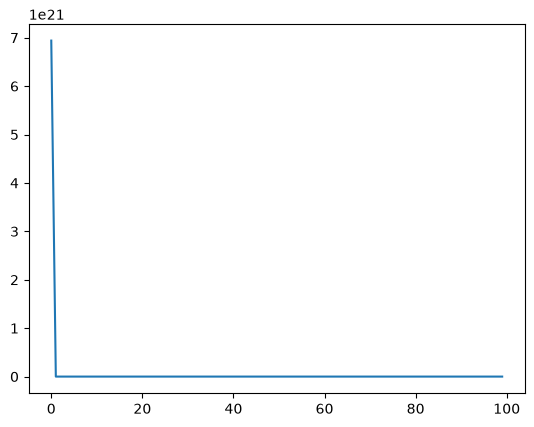

In [80]:
# Plot training and validation loss
import matplotlib.pyplot as plt
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Rent Prediction Model Training")
plt.legend()
plt.show()